In [144]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
import torchmetrics
import torchvision as tv

## 0. Computer vision libraries

* Torchvision - base domain
* torchvision.datasets - get datasets and data functions for computer vision
* torchvision.models - get pretrained computer vision models 
* torchvision.transforms - functions for manipulating your vision data (images) to be suitable for ML models
* torch.utils.data.Dataset - base dataset for PyTorch
* torch.utils.data.DataLoader - creates a Python iterable over a dataset

In [145]:
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

## 1. Get a dataset

In [146]:
# fashion MNIST dataset
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None #target_transform is used to transform the labels of the dataset, if needed. In this case, it's set to None, meaning no transformation will be applied to the labels.
)
train_data[0]

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [147]:
len(train_data), len(test_data)

(60000, 10000)

In [148]:
# see the first training sample
image, label = train_data[0]

In [149]:
train_data.classes, train_data.class_to_idx

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 {'T-shirt/top': 0,
  'Trouser': 1,
  'Pullover': 2,
  'Dress': 3,
  'Coat': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'Bag': 8,
  'Ankle boot': 9})

In [150]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [151]:
print(f"Image shape: {image.shape} -> [color_channels, height, width]")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]


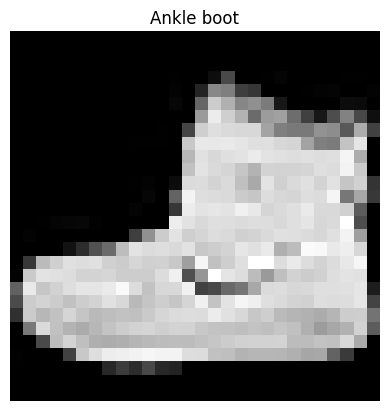

In [152]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.axis(False);

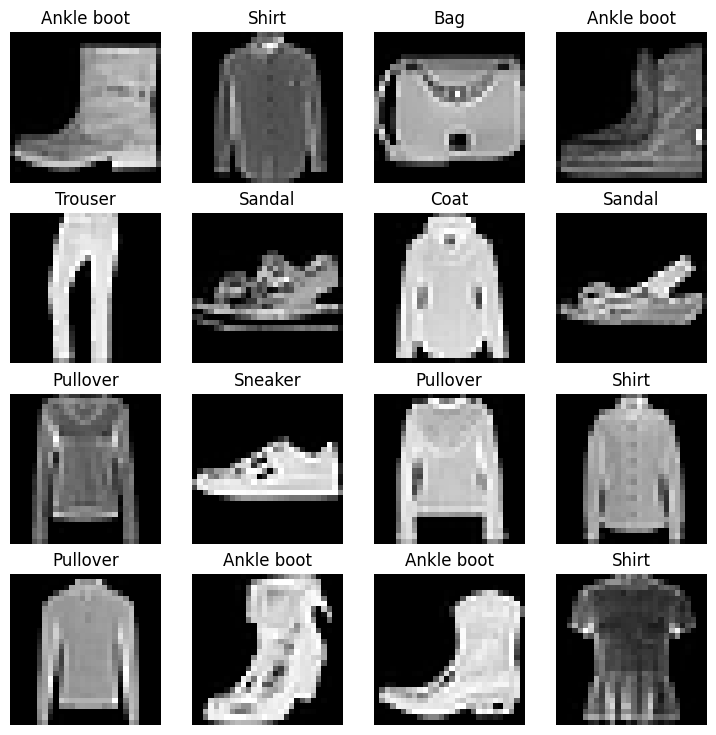

In [153]:
# batch size, height, width, color channels -> 10 labels output
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(train_data.classes[label])
    plt.axis(False)

In [154]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

## DataLoader
* Dataloader turns our dataset into a python iterable
* turns data into mini-batches - for more computational stability
* updates weights after each mini-batch in epohh

In [155]:
#32 sample per batch, 1 color channel, 28 height, 28 width

BATCH_SIZE = 32

from torch.utils.data import DataLoader
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x13c52c7d0>,
 <torch.utils.data.dataloader.DataLoader at 0x13c52c910>)

In [156]:
print(f'DataLoader length: {len(train_dataloader)}, {len(test_dataloader)}')

DataLoader length: 1875, 313


In [157]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape #particular batch of features and labels

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Label: 8, Class name: Bag


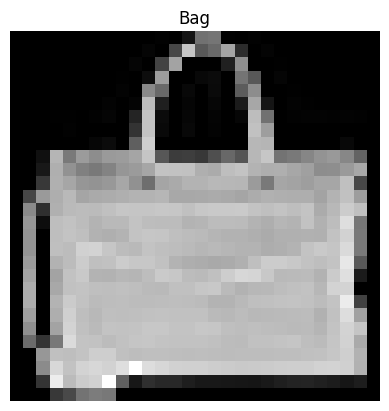

In [158]:
# Show a sample batch of images and labels from the training dataloader
#torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.axis(False)
print(f"Image shape: {img.shape} -> [color_channels, height, width]")
print(f"Label: {label}, Class name: {train_data.classes[label]}")

## 3. Build a baseline model

When starting a series of ML modelling experiments - start simple with baseline.
Then try to improve it by hyperparameter tuning
Start simple -> add complexity

In [159]:
#flatten model

flatten_model = nn.Flatten()

#
x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flatten: {x.shape}")
print(f"Shape after flatten: {output.shape}")  #color channel, height x width

Shape before flatten: torch.Size([1, 28, 28])
Shape after flatten: torch.Size([1, 784])


In [160]:
output.squeeze()

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
        0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2863, 0.0000, 0.0000, 0.0078, 

In [161]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units:int, output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), #flattens the input tensor into a 1D tensor, preserving the batch size. This is necessary because fully connected layers (like nn.Linear) expect 1D input.
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [162]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, #28x28=784, 1 color channel, 28 height, 28 width
                              hidden_units=10, #how many hidden units we want to have in the hidden layer. This is a hyperparameter that can be tuned based on the complexity of the task and the amount of data available.
                              output_shape=len(train_data.classes) #one for each class in the dataset (10 classes in total for FashionMNIST)
                    ).to('cpu')
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [163]:
dummy_x = torch.rand(1, 1, 28, 28) #batch size, color channel, height, width
model_0(dummy_x)    

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [164]:
# loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.01)
##
import requests
from pathlib import Path
#download helper functions
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download.")
else:
    print("Downloading helper_functions.py...")
    url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py" #raw.githubusercontent.com is a domain that serves raw files from GitHub repositories. In this case, it's being used to download the helper_functions.py file from the specified GitHub repository.
    response = requests.get(url)
    with open("helper_functions.py", "wb") as f:
        f.write(response.content)
    print("Downloaded helper_functions.py.")

helper_functions.py already exists, skipping download.


In [165]:
from helper_functions import accuracy_fn

## 3.2 Creating a function to time our experiments

ML codes are compared:
1. How accurate
2. How quick

In [166]:
## function to measure time taken for training and testing
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    """Prints difference between start and end time."""
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

start_time = timer()
## some code to train the model here
end_time = timer()
print_train_time(start=start_time, end=end_time, device=str(next(model_0.parameters()).device))



Train time on cpu: 0.000 seconds


8.167000487446785e-06

In [167]:
## 3.3 create a training loop and testing loop

## 3.3 Create a training loop on batches of data

1. Loop through epochs
2. Loop through training batches, perform training steps, calc train loss
3. Loop through testing batchesm perform testing steps
4. print what happens
5. time it all

In [168]:
from tqdm.auto import tqdm #best tqdm for task

# Set seed and start time
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# set the number of epochs for faster training and testing
epochs = 3

#
for epoch in tqdm(range(epochs)): #wrap iterator with tqdm for progress bar
    print(f"Epoch: {epoch}\n---------")
    train_loss = 0 #accumulate the loss per epoch and epoch
    # add a loop through batches
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        # forward pass
        y_pred = model_0(X)
        # calc loss
        loss = loss_fn(y_pred, y)
        train_loss += loss #accumulate the loss per epoch and epoch
        # optimizer
        optimizer.zero_grad()
        # backward pass
        loss.backward()
        #step the optimizer
        optimizer.step()

        #print whats happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")
    # divide total train by length of the train dataloader to get the average loss per epoch
    train_loss /= len(train_dataloader)
    # testing loop
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test)
            test_loss += loss_fn(test_pred, y_test)
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        # divide total test loss and accuracy by length of the test dataloader to get the average loss and accuracy per epoch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    # print out what's happening
    print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.5645 | Test loss: 0.5088 | Test accuracy: 82.2384%

Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.5013 | Test loss: 0.4899 | Test accuracy: 83.0471%

Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.4809 | Test loss: 0.5726 | Test accuracy: 80.4712%

Train time on cpu: 6.475 seconds


In [169]:
next(model_0.parameters()).device

device(type='cpu')

## 4. Make predictions and get Model 0 results

In [170]:
torch.manual_seed(42)

def eval_model(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)
            loss+= loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc,
            "model_device": str(next(model.parameters()).device)}

# model0 results_model_0 = eval_model(model=model_0,

model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

In [171]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5725627541542053,
 'model_acc': 80.47124600638978,
 'model_device': 'cpu'}

## 5. Setup device agnostic code (for GPU - MPS)

In [172]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
device


'mps'

## 6 use nonlinear activation for better classification

In [195]:
## model_1 building a CNN model for FashionMNIST dataset
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), #flattens the input tensor into a 1D tensor, preserving the batch size. This is necessary because fully connected layers (like nn.Linear) expect 1D input.
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU() #add a ReLU activation function after the second linear layer to introduce non-linearity and allow the model to learn more complex patterns in the data.  
        )

    def forward(self, x):
        return self.layer_stack(x)

In [196]:
torch.manual_seed(42)
model1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(train_data.classes)).to(device)
model1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [197]:
model1.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
                     device='mps:0')),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163], device='mps:0')),
             ('layer_stack.3.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1

In [198]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model1.parameters(), lr=0.1)

### 6.2 Functionizing train and test loops

* training loop - train_step()
* test loop - test_step()

In [199]:
def train_step(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device = device,
        accuracy_fn= accuracy_fn
):
    """Performs a single training step for a model on a data_loader."""
    train_loss, train_acc = 0,0
    #put model on a target device
    model.train()
    for batch, (X,y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        # forward pass
        y_pred = model(X)
        # calc loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        # optimizer
        optimizer.zero_grad()
        # backward pass
        loss.backward()
        # step the optimizer
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}%")
    #return train_loss, train_acc

In [200]:
def test_step(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        device: torch.device = device,
        accuracy_fn= accuracy_fn
):
    """Performs a single testing step for a model on a data_loader."""
    test_loss, test_acc = 0,0
    #put model on a target device
    model.eval()
    with torch.inference_mode():
        for batch, (X,y) in enumerate(data_loader):
            X, y = X.to(device), y.to(device)
            # forward pass
            test_pred = model(X)
            # calc loss
            loss = loss_fn(test_pred, y)
            test_loss += loss.item()
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}%")
    #return test_loss, test_acc

In [201]:
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch+1}\n-------------------------------")
    train_step(model=model1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               device=device,
               accuracy_fn=accuracy_fn)
    test_step(model=model1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              device=device,
              accuracy_fn=accuracy_fn)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,end=train_time_end_on_gpu,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
-------------------------------
Train loss: 1.0588 | Train accuracy: 62.1917%
Test loss: 0.9951 | Test accuracy: 64.1274%
Epoch: 2
-------------------------------
Train loss: 0.9133 | Train accuracy: 66.3967%
Test loss: 0.9051 | Test accuracy: 66.8630%
Epoch: 3
-------------------------------
Train loss: 0.8798 | Train accuracy: 67.2433%
Test loss: 0.8948 | Test accuracy: 66.4637%
Train time on mps: 16.135 seconds


In [202]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5725627541542053,
 'model_acc': 80.47124600638978,
 'model_device': 'cpu'}

In [203]:
torch.manual_seed(42)

def eval_model(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            #make sure the data is on the same device as the model
            X, y = X.to(next(model.parameters()).device), y.to(next(model.parameters()).device)
            y_pred = model(X)
            loss+= loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc,
            "model_device": str(next(model.parameters()).device)}

# model0 results_model_0 = eval_model(model=model_0,

model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

In [204]:
model1_results = eval_model(model=model1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)


In [205]:
model1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.8947634696960449,
 'model_acc': 66.46365814696486,
 'model_device': 'mps:0'}